In [211]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal, List, Annotated
from pydantic import Field, BaseModel

In [212]:
class SentimentScema(BaseModel):
    sentiment: Annotated[Literal["positive", "negative", "neutral"], Field(description="The sentiment of the email")]

class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [213]:
model = ChatOllama(model="llama3.2:3b")
model

ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b')

In [214]:
model_structure_output1 = model.with_structured_output(SentimentScema)
model_structure_output1

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b'), kwargs={'format': {'properties': {'sentiment': {'description': 'The sentiment of the email', 'enum': ['positive', 'negative', 'neutral'], 'title': 'Sentiment', 'type': 'string'}}, 'required': ['sentiment'], 'title': 'SentimentScema', 'type': 'object'}, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema'}, 'schema': <class '__main__.SentimentScema'>}}, config={}, config_factories=[])
| PydanticOutputParser(pydantic_object=<class '__main__.SentimentScema'>)

In [215]:
model_structure_output2 = model.with_structured_output(DiagnosisSchema)
model_structure_output2

_ChatModelBinding(bound=ChatOllama(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2:3b'), kwargs={'format': {'properties': {'issue_type': {'description': 'The category of issue mentioned in the review', 'enum': ['UX', 'Performance', 'Bug', 'Support', 'Other'], 'title': 'Issue Type', 'type': 'string'}, 'tone': {'description': 'The emotional tone expressed by the user', 'enum': ['angry', 'frustrated', 'disappointed', 'calm'], 'title': 'Tone', 'type': 'string'}, 'urgency': {'description': 'How urgent or critical the issue appears to be', 'enum': ['low', 'medium', 'high'], 'title': 'Urgency', 'type': 'string'}}, 'required': ['issue_type', 'tone', 'urgency'], 'title': 'DiagnosisSchema', 'type': 'object'}, 'ls_structured_output_format': {'kwargs': {'method': 'json_schema'}, 'schema': <class '__main__.DiagnosisSchema'>}}, config={}, config_factories=[])
| PydanticOutputParser(pydantic_object=<class '__main__.DiagnosisSchema'>)

In [216]:
class ReviewSentiment(TypedDict):
    review: Literal["positive", "negative"]
    result:str
    diagnosis: str
    response: str
    response_dev: str

In [217]:
def find_sentiment(state:ReviewSentiment):
    prompt = f"""
    You are a sentiment analysis expert.
    Analyze the review and determine the sentiment of the review.
    Review: {state['review']}
    """
    result = model_structure_output1.invoke(prompt).sentiment
    return {"result": result}

In [218]:
def positive_response(state:ReviewSentiment):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website."""
      
    response = model.invoke(prompt).content
    return {"response": response}

In [219]:
def diagnosis_result(state:ReviewSentiment):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    Return issue_type, tone, and urgency.
    """
    result = model_structure_output2.invoke(prompt)
    dump = result.model_dump()
    dump_json = result.model_dump_json()
    # validate the output against the DiagnosisSchema
    validated_output = DiagnosisSchema(**dump)
    print(validated_output)
    print(type(validated_output))
    print(dump)
    print(type(dump))
    print(dump_json)
    print(type(dump_json))
    return {"diagnosis": dump}

In [220]:
def negative_response(state: ReviewSentiment):
    diagnosis = state['diagnosis']

    prompt = f"""You are a support assistant.
    The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """
    response = model.invoke(prompt).content

    return {'response': response}

In [221]:
def check_sentiment(state: ReviewSentiment):
    if state["result"] == "positive":
        return "positive_response"
    else:
        return "diagnosis_result"

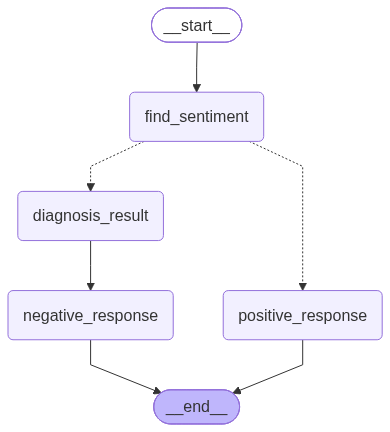

In [222]:
graph = StateGraph(ReviewSentiment) 
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("diagnosis_result", diagnosis_result)
graph.add_node("negative_response", negative_response)

graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment,[
    "positive_response",
    "diagnosis_result"
])

graph.add_edge("positive_response", END)

graph.add_edge("diagnosis_result", "negative_response")
graph.add_edge("negative_response", END)


workflow = graph.compile()
workflow

In [223]:
initial_state = {"review": "The product is amazing and exceeded my expectations!"}

response = workflow.invoke(initial_state)
response

{'review': 'The product is amazing and exceeded my expectations!',
 'result': 'positive',
 'response': 'Here\'s a warm thank-you message:\n\n"Dear valued customer,\n\nWe\'re absolutely thrilled to hear that our product exceeded your expectations and that you\'re loving it! We\'re so grateful for customers like you who take the time to share their feedback with us.\n\nAs a small token of our appreciation, we\'d love to ask: could you spare a moment to leave some feedback on our website? Your input helps us improve and provide the best possible experience for all our customers. Your support means the world to us!\n\nThank you again for your kind words and for being an amazing customer. We\'re honored to have you on board!\n\nWarm regards, [Your Name/Company Name]"'}

In [224]:
intial_state={
    'review': "The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement."
}
response = workflow.invoke(intial_state)
response

issue_type='Performance' tone='frustrated' urgency='high'
<class '__main__.DiagnosisSchema'>
{'issue_type': 'Performance', 'tone': 'frustrated', 'urgency': 'high'}
<class 'dict'>
{"issue_type":"Performance","tone":"frustrated","urgency":"high"}
<class 'str'>


{'review': 'The software has potential, but the performance is inconsistent and the interface can be confusing at times. Frequent bugs and slow customer support made the overall experience frustrating. Needs significant improvement.',
 'result': 'negative',
 'diagnosis': {'issue_type': 'Performance',
  'tone': 'frustrated',
  'urgency': 'high'},
 'response': 'Dear [User\'s Name],\n\nI want to start by apologizing for the frustration you experienced with your performance issue. I can imagine how challenging and time-consuming it must have been for you, and I\'m truly sorry that we weren\'t able to resolve it quickly enough.\n\nI\'ve reviewed the issue you reported, and I\'ve identified the root cause. Unfortunately, it appears that [briefly describe the cause, e.g., "a misconfigured system parameter" or "an unexpected error in our code"]. I want to assure you that we\'re taking immediate action to rectify the situation.\n\nTo mitigate the impact of this issue, I\'m going to [provide a c